In [2]:
from torch.distributions import Categorical
import seaborn as sns
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import gymnasium as gym
from gymnasium import spaces
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),
    'figure.dpi': 100
})

- **State $s$**: Observation Space (continuous, **13** dimensions):
  - Day of year (sin/cos encoded): 2
  - Season progress: 1
  - Recent rainfall (7d, 14d, 30d sums): 3
  - Current soil moisture: 1
  - Recent forecast (next 7 days mean): 1
  - Crop status (planted flag, days since planting, growth stage): 3
  - Season progress: 1
  - Rainfall scale indicator (dry/wet year): 1
- **Action $a$**: Discrete (4 actions):
  - 0: Wait (do nothing)
  - 1: Plant short-cycle variety (90 days, high drought tolerance)
  - 2: Plant medium-cycle variety (110 days, medium drought tolerance)
  - 3: Plant long-cycle variety (130 days, LOW drought tolerance - risky in dry years!)
- **Reward $r$**:
  - At harvest: efficiency-based reward (yield / potential_yield) - normalized across varieties
  - During planting: weather-aware bonuses/penalties based on conditions
  - Waiting: small penalties, larger if conditions are good

We use **PPO (Proximal Policy Optimization)** with Actor-Critic:

$$L^{CLIP}(\theta) = \mathbb{E}\left[\min\left(r_t(\theta) A_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) A_t\right)\right]$$

Where:

- $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$ is the probability ratio
- $A_t$ is the advantage estimate (typically GAE)
- $\epsilon$ is the clipping parameter (typically 0.2)


In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PROCESSED = Path('../data/processed')
MODELS_DIR = Path('../models')
sys.path.insert(0, str(MODELS_DIR.resolve()))

df = pd.read_csv(DATA_PROCESSED / 'rainfall_features_full.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Region', 'Date']).reset_index(drop=True)

region_df = df[df['Region'] == 'Region1'].copy()
rainfall_data = region_df['Mean'].values  

from crop_calendar_env import CropCalendarEnv
from gymnasium.envs.registration import register

try:
    register(
        id='CropCalendar-v0',
        entry_point='crop_calendar_env:CropCalendarEnv',
    )
    print("Environment registered as 'CropCalendar-v0'")
except Exception as e:
    print(f"Environment already registered or error: {e}")


env_train = gym.make('CropCalendar-v0', rainfall_data=rainfall_data)
env_test = gym.make('CropCalendar-v0', rainfall_data=rainfall_data)
print(f"Environments created with {len(rainfall_data)} rainfall observations")

Environment registered as 'CropCalendar-v0'
Environments created with 13514 rainfall observations


In [4]:
class MLPBackbone(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0.0)
    
    def forward(self, x):
        return self.net(x)


class ActorCritic(nn.Module):
    """
    Actor-Critic network for PPO.
    - Actor: outputs action logits
    - Critic: outputs state value estimate
    """
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128, dropout: float = 0.1):
        super().__init__()
        self.actor = MLPBackbone(obs_dim, hidden_dim, action_dim, dropout)
        self.critic = MLPBackbone(obs_dim, hidden_dim, 1, dropout)
        
        nn.init.orthogonal_(self.actor.net[-1].weight, gain=0.01)
        
    def forward(self, state):
        action_logits = self.actor(state)
        value = self.critic(state)
        return action_logits, value
    
    def get_action(self, state, deterministic=False):
        """Sample action from policy."""
        action_logits, value = self(state)
        dist = Categorical(logits=action_logits)
        
        if deterministic:
            action = action_logits.argmax(dim=-1)
        else:
            action = dist.sample()
            
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        
        return action, log_prob, value.squeeze(-1), entropy
    
    def evaluate_actions(self, states, actions):
        """Evaluate log probs and values for given state-action pairs."""
        action_logits, values = self(states)
        dist = Categorical(logits=action_logits)
        
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        
        return log_probs, values.squeeze(-1), entropy

In [5]:
class RolloutBuffer:
    """Stores trajectories for PPO updates."""
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []
        
    def store(self, state, action, log_prob, reward, value, done):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)
    
    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.log_probs.clear()
        self.rewards.clear()
        self.values.clear()
        self.dones.clear()
    
    def get(self):
        return (
            torch.stack(self.states),
            torch.tensor(self.actions),
            torch.stack(self.log_probs),
            torch.tensor(self.rewards, dtype=torch.float32),
            torch.stack(self.values),
            torch.tensor(self.dones, dtype=torch.float32)
        )

In [6]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """
    Compute Generalized Advantage Estimation (GAE).
    
    GAE-Lambda: A_t = sum_{l=0}^{inf} (gamma * lam)^l * delta_{t+l}
    where delta_t = r_t + gamma * V(s_{t+1}) - V(s_t)
    
    Args:
        rewards: tensor of rewards
        values: tensor of value estimates
        dones: tensor of done flags
        gamma: discount factor
        lam: GAE lambda parameter
        
    Returns:
        advantages: GAE estimates
        returns: discounted returns (advantages + values)
    """
    advantages = torch.zeros_like(rewards)
    last_gae = 0
    
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_value = 0  # Terminal state
        else:
            next_value = values[t + 1]
        
        # TD error: delta = r + gamma * V(s') - V(s)
        delta = rewards[t] + gamma * next_value * (1 - dones[t]) - values[t]
        
        # GAE: A_t = delta_t + gamma * lam * A_{t+1}
        advantages[t] = last_gae = delta + gamma * lam * (1 - dones[t]) * last_gae
    
    returns = advantages + values
    return advantages, returns

In [7]:
def ppo_update(agent, optimizer, buffer, clip_epsilon=0.2, value_coef=0.5, entropy_coef=0.01, max_grad_norm=0.5, epochs=4, batch_size=64):
    """
    PPO clipped objective update.
    
    Args:
        agent: ActorCritic network
        optimizer: optimizer
        buffer: RolloutBuffer with collected trajectories
        clip_epsilon: PPO clipping parameter
        value_coef: value loss coefficient
        entropy_coef: entropy bonus coefficient
        max_grad_norm: gradient clipping
        epochs: number of optimization epochs per update
        batch_size: minibatch size
        
    Returns:
        dict of training metrics
    """
    states, actions, old_log_probs, rewards, old_values, dones = buffer.get()
    
    with torch.no_grad():
        advantages, returns = compute_gae(rewards, old_values.squeeze(), dones)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    
    total_policy_loss = 0
    total_value_loss = 0
    total_entropy = 0
    num_updates = 0
    
    indices = np.arange(len(states))
    
    for _ in range(epochs):
        np.random.shuffle(indices)
        
        for start in range(0, len(states), batch_size):
            end = start + batch_size
            batch_idx = indices[start:end]
            
            batch_states = states[batch_idx]
            batch_actions = actions[batch_idx]
            batch_old_log_probs = old_log_probs[batch_idx]
            batch_advantages = advantages[batch_idx]
            batch_returns = returns[batch_idx]
            
            new_log_probs, new_values, entropy = agent.evaluate_actions(batch_states, batch_actions)
            
            ratio = (new_log_probs - batch_old_log_probs).exp()
            
            surr1 = ratio * batch_advantages
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * batch_advantages
            policy_loss = -torch.min(surr1, surr2).mean()
            
            value_loss = F.mse_loss(new_values, batch_returns)
            
            entropy_loss = -entropy.mean()
            
            loss = policy_loss + value_coef * value_loss + entropy_coef * entropy_loss
            
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()
            
            total_policy_loss += policy_loss.item()
            total_value_loss += value_loss.item()
            total_entropy += entropy.mean().item()
            num_updates += 1
    
    return {
        'policy_loss': total_policy_loss / num_updates,
        'value_loss': total_value_loss / num_updates,
        'entropy': total_entropy / num_updates
    }

In [8]:
def collect_rollout(env, agent, buffer, num_steps):
    """
    Collect trajectories by running policy in environment.
    
    Args:
        env: gymnasium environment
        agent: ActorCritic network
        buffer: RolloutBuffer to store transitions
        num_steps: number of steps to collect
        
    Returns:
        episode_rewards: list of completed episode rewards
    """
    state, info = env.reset()
    episode_reward = 0
    episode_rewards = []
    
    agent.eval()
    with torch.no_grad():
        for _ in range(num_steps):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action, log_prob, value, _ = agent.get_action(state_tensor)
            
            next_state, reward, terminated, truncated, info = env.step(action.item())
            done = terminated or truncated
            
            buffer.store(
                state_tensor.squeeze(0),
                action.item(),
                log_prob.squeeze(0),
                reward,
                value.squeeze(0),
                float(done)
            )
            
            episode_reward += reward
            
            if done:
                episode_rewards.append(episode_reward)
                episode_reward = 0
                state, info = env.reset()
            else:
                state = next_state
    
    return episode_rewards

In [9]:
def train_ppo(env, agent, optimizer, num_iterations=500, steps_per_iter=1024, 
            clip_epsilon=0.2, value_coef=0.5, entropy_coef=0.01, log_interval=10):
    """
    Main PPO training loop.
    
    Args:
        env: gymnasium environment
        agent: ActorCritic network
        optimizer: optimizer
        num_iterations: number of training iterations
        steps_per_iter: environment steps per iteration
        clip_epsilon: PPO clipping parameter
        value_coef: value loss coefficient
        entropy_coef: entropy bonus coefficient
        log_interval: logging frequency
        
    Returns:
        training_history: dict of metrics over training
    """
    buffer = RolloutBuffer()
    
    history = {
        'episode_rewards': [],
        'mean_rewards': [],
        'policy_losses': [],
        'value_losses': [],
        'entropies': []
    }
    
    all_episode_rewards = []
    
    for iteration in range(num_iterations):
        buffer.clear()
        
        episode_rewards = collect_rollout(env, agent, buffer, steps_per_iter)
        all_episode_rewards.extend(episode_rewards)
        
        agent.train()
        metrics = ppo_update(
            agent, optimizer, buffer,
            clip_epsilon=clip_epsilon,
            value_coef=value_coef,
            entropy_coef=entropy_coef
        )
        
        history['policy_losses'].append(metrics['policy_loss'])
        history['value_losses'].append(metrics['value_loss'])
        history['entropies'].append(metrics['entropy'])
        
        if episode_rewards:
            mean_reward = np.mean(episode_rewards)
            history['episode_rewards'].extend(episode_rewards)
            history['mean_rewards'].append(mean_reward)
        
        if (iteration + 1) % log_interval == 0:
            recent_rewards = all_episode_rewards[-100:] if all_episode_rewards else [0]
            print(f"Iter {iteration+1}/{num_iterations} | "
                f"Mean Reward (100 ep): {np.mean(recent_rewards):.2f} | "
                f"Policy Loss: {metrics['policy_loss']:.4f} | "
                f"Value Loss: {metrics['value_loss']:.4f} | "
                f"Entropy: {metrics['entropy']:.4f}")
    
    return history

In [10]:
HIDDEN_DIM = 128
DROPOUT = 0.1
LEARNING_RATE = 3e-4
NUM_ITERATIONS = 300
STEPS_PER_ITER = 1024
CLIP_EPSILON = 0.2
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01

obs_dim = env_train.observation_space.shape[0]
action_dim = env_train.action_space.n

print(f"Observation dim: {obs_dim}")
print(f"Action dim: {action_dim}")

agent = ActorCritic(obs_dim, action_dim, HIDDEN_DIM, DROPOUT)
optimizer = optim.Adam(agent.parameters(), lr=LEARNING_RATE)

print(f"\nAgent architecture:")
print(agent)

Observation dim: 13
Action dim: 4

Agent architecture:
ActorCritic(
  (actor): MLPBackbone(
    (net): Sequential(
      (0): Linear(in_features=13, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=128, out_features=4, bias=True)
    )
  )
  (critic): MLPBackbone(
    (net): Sequential(
      (0): Linear(in_features=13, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)


In [11]:
print("Starting PPO training...")
print("=" * 60)

history = train_ppo(
    env_train, agent, optimizer,
    num_iterations=NUM_ITERATIONS,
    steps_per_iter=STEPS_PER_ITER,
    clip_epsilon=CLIP_EPSILON,
    value_coef=VALUE_COEF,
    entropy_coef=ENTROPY_COEF,
    log_interval=20
)

print("=" * 60)
print("Training complete!")

Starting PPO training...
Iter 20/300 | Mean Reward (100 ep): 5.43 | Policy Loss: -0.0041 | Value Loss: 0.5907 | Entropy: 1.3385
Iter 40/300 | Mean Reward (100 ep): 6.04 | Policy Loss: -0.0034 | Value Loss: 0.3019 | Entropy: 1.3516
Iter 60/300 | Mean Reward (100 ep): 6.97 | Policy Loss: -0.0020 | Value Loss: 0.3252 | Entropy: 1.2967
Iter 80/300 | Mean Reward (100 ep): 6.83 | Policy Loss: -0.0037 | Value Loss: 0.3175 | Entropy: 1.3242
Iter 100/300 | Mean Reward (100 ep): 6.88 | Policy Loss: -0.0006 | Value Loss: 0.2072 | Entropy: 1.3270
Iter 120/300 | Mean Reward (100 ep): 7.03 | Policy Loss: -0.0002 | Value Loss: 0.3961 | Entropy: 1.2634
Iter 140/300 | Mean Reward (100 ep): 7.25 | Policy Loss: -0.0035 | Value Loss: 0.1314 | Entropy: 1.2264
Iter 160/300 | Mean Reward (100 ep): 7.22 | Policy Loss: -0.0028 | Value Loss: 0.2448 | Entropy: 1.2479
Iter 180/300 | Mean Reward (100 ep): 7.18 | Policy Loss: -0.0029 | Value Loss: 0.1070 | Entropy: 1.2392
Iter 200/300 | Mean Reward (100 ep): 6.72 |

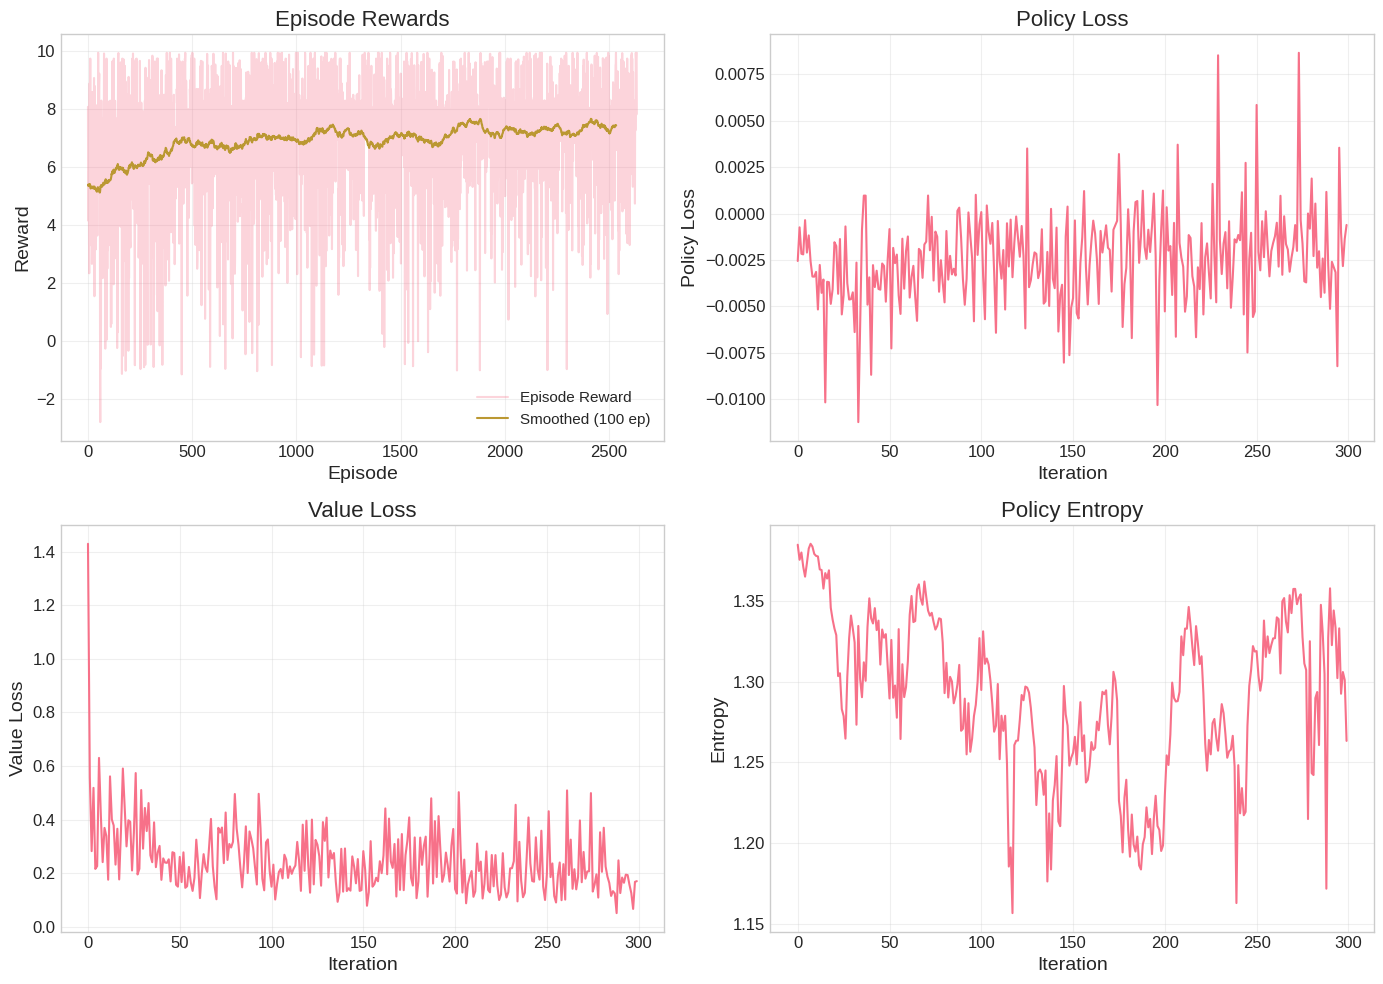

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if history['episode_rewards']:
    axes[0, 0].plot(history['episode_rewards'], alpha=0.3, label='Episode Reward')
    # Smoothed rewards
    window = min(100, len(history['episode_rewards']))
    if window > 1:
        smoothed = np.convolve(history['episode_rewards'], 
                            np.ones(window)/window, mode='valid')
        axes[0, 0].plot(smoothed, label=f'Smoothed ({window} ep)')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].set_title('Episode Rewards')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['policy_losses'])
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Policy Loss')
axes[0, 1].set_title('Policy Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['value_losses'])
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Value Loss')
axes[1, 0].set_title('Value Loss')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['entropies'])
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Entropy')
axes[1, 1].set_title('Policy Entropy')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
def evaluate_agent(env, agent, num_episodes=100, deterministic=True):
    """Evaluate trained agent over multiple episodes."""
    agent.eval()
    episode_rewards = []
    episode_lengths = []
    episode_yields = []
    planting_days = []
    varieties_chosen = []  # Track variety selection
    rainfall_scales = []   # Track dry/wet year conditions
    
    with torch.no_grad():
        for _ in range(num_episodes):
            state, info = env.reset()
            done = False
            episode_reward = 0
            steps = 0
            planted_day = None
            variety = None
            
            # Get rainfall scale for this episode (last dim of obs)
            rainfall_scale = state[-1] + 1.0  # Convert from normalized to actual scale
            rainfall_scales.append(rainfall_scale)
            
            while not done:
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                action, _, _, _ = agent.get_action(state_tensor, deterministic=deterministic)
                
                # Track planting decision
                if action.item() > 0 and planted_day is None:
                    planted_day = steps
                    variety = action.item()  # 1=short, 2=medium, 3=long
                
                state, reward, terminated, truncated, info = env.step(action.item())
                done = terminated or truncated
                episode_reward += reward
                steps += 1
            
            episode_rewards.append(episode_reward)
            episode_lengths.append(steps)
            episode_yields.append(info.get('current_yield', 0))
            if planted_day is not None:
                planting_days.append(planted_day)
            if variety is not None:
                varieties_chosen.append(variety)
    
    return {
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'mean_length': np.mean(episode_lengths),
        'mean_yield': np.mean(episode_yields),
        'std_yield': np.std(episode_yields),
        'mean_planting_day': np.mean(planting_days) if planting_days else None,
        'std_planting_day': np.std(planting_days) if planting_days else None,
        'rewards': episode_rewards,
        'yields': episode_yields,
        'planting_days': planting_days,
        'varieties': varieties_chosen,
        'rainfall_scales': rainfall_scales
    }

In [14]:
eval_results = evaluate_agent(env_test, agent, num_episodes=100)

print(f"Evaluation Results (100 episodes):")
print(f"  Mean Reward: {eval_results['mean_reward']:.2f} ± {eval_results['std_reward']:.2f}")
print(f"  Mean Episode Length: {eval_results['mean_length']:.1f} days")
print(f"  Mean Yield: {eval_results['mean_yield']:.2f} ± {eval_results['std_yield']:.2f} t/ha")
if eval_results['mean_planting_day'] is not None:
    print(f"  Mean Planting Day: {eval_results['mean_planting_day']:.1f} ± {eval_results['std_planting_day']:.1f}")

# Variety distribution
if eval_results['varieties']:
    variety_names = {1: 'Short (90d)', 2: 'Medium (110d)', 3: 'Long (130d)'}
    print(f"\nVariety Selection:")
    for v in [1, 2, 3]:
        count = eval_results['varieties'].count(v)
        pct = count / len(eval_results['varieties']) * 100
        print(f"  {variety_names[v]}: {count} episodes ({pct:.1f}%)")

Evaluation Results (100 episodes):
  Mean Reward: 7.81 ± 1.58
  Mean Episode Length: 109.8 days
  Mean Yield: 5.16 ± 1.34 t/ha
  Mean Planting Day: 0.0 ± 0.0

Variety Selection:
  Short (90d): 31 episodes (31.0%)
  Medium (110d): 39 episodes (39.0%)
  Long (130d): 30 episodes (30.0%)


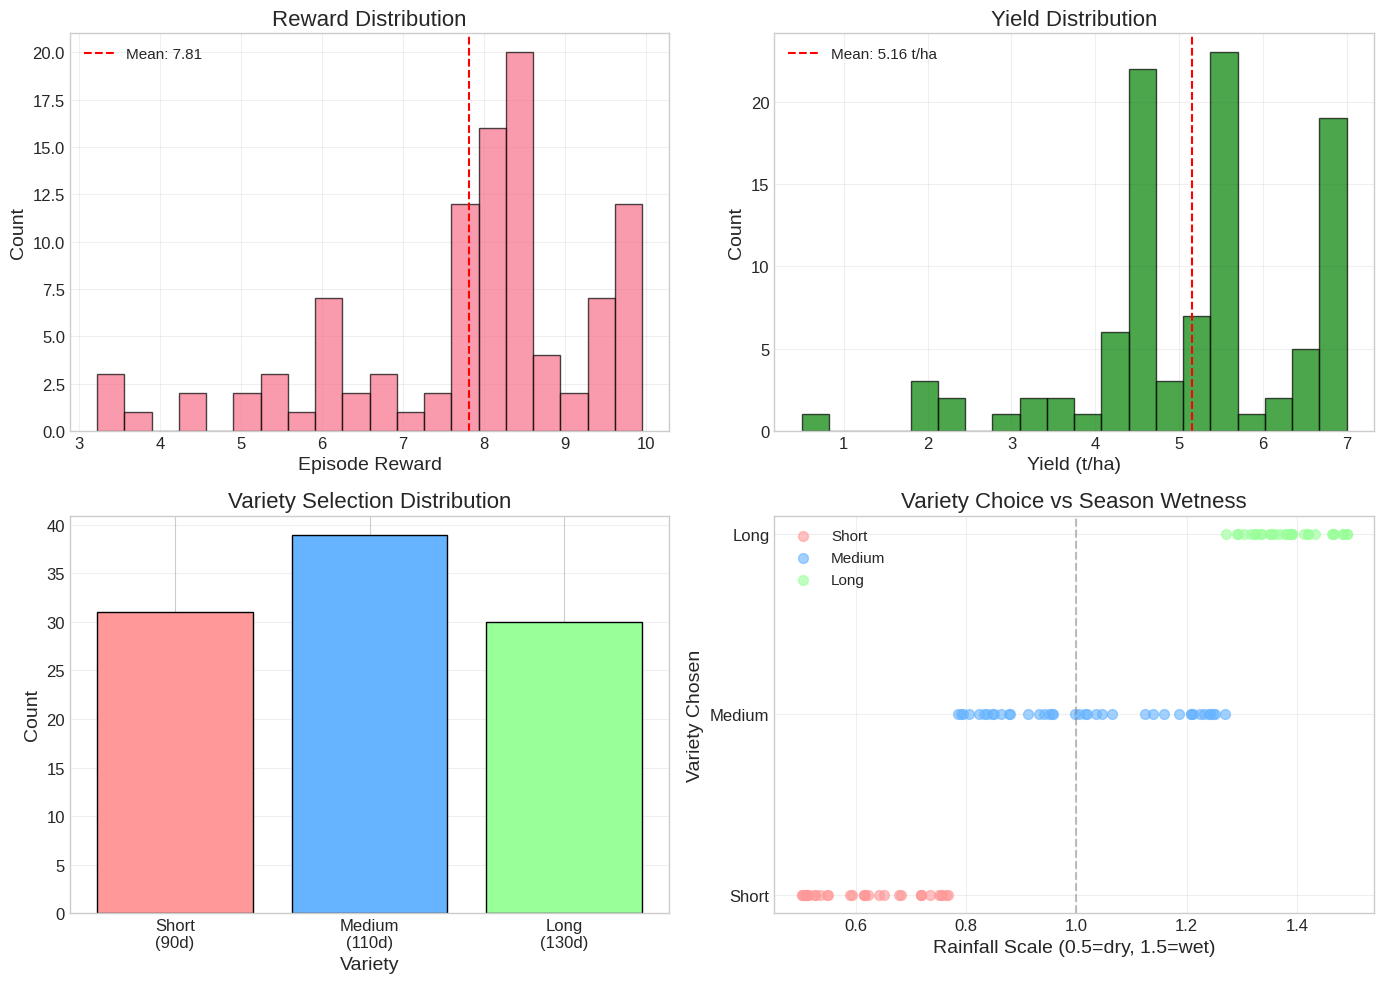

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(eval_results['rewards'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(eval_results['mean_reward'], color='red', linestyle='--', label=f'Mean: {eval_results["mean_reward"]:.2f}')
axes[0, 0].set_xlabel('Episode Reward')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Reward Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(eval_results['yields'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(eval_results['mean_yield'], color='red', linestyle='--', label=f'Mean: {eval_results["mean_yield"]:.2f} t/ha')
axes[0, 1].set_xlabel('Yield (t/ha)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Yield Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

variety_counts = [eval_results['varieties'].count(v) for v in [1, 2, 3]]
variety_labels = ['Short\n(90d)', 'Medium\n(110d)', 'Long\n(130d)']
colors = ['#ff9999', '#66b3ff', '#99ff99']
axes[1, 0].bar(variety_labels, variety_counts, color=colors, edgecolor='black')
axes[1, 0].set_xlabel('Variety')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Variety Selection Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')

if eval_results['varieties'] and eval_results['rainfall_scales']:
    varieties = np.array(eval_results['varieties'])
    scales = np.array(eval_results['rainfall_scales'][:len(varieties)])
    
    for v, name, color in [(1, 'Short', '#ff9999'), (2, 'Medium', '#66b3ff'), (3, 'Long', '#99ff99')]:
        mask = varieties == v
        if mask.any():
            axes[1, 1].scatter(scales[mask], [v]*mask.sum(), alpha=0.6, s=50, c=color, label=name)
    
    axes[1, 1].set_xlabel('Rainfall Scale (0.5=dry, 1.5=wet)')
    axes[1, 1].set_ylabel('Variety Chosen')
    axes[1, 1].set_yticks([1, 2, 3])
    axes[1, 1].set_yticklabels(['Short', 'Medium', 'Long'])
    axes[1, 1].set_title('Variety Choice vs Season Wetness')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='Normal')

plt.tight_layout()
plt.show()

In [16]:
MODEL_SAVE_PATH = MODELS_DIR / 'ppo_crop_calendar.pt'

torch.save({
    'agent_state_dict': agent.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hyperparameters': {
        'hidden_dim': HIDDEN_DIM,
        'dropout': DROPOUT,
        'learning_rate': LEARNING_RATE,
        'obs_dim': obs_dim,
        'action_dim': action_dim
    },
    'training_history': history
}, MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to ../models/ppo_crop_calendar.pt


## Visual Environment Demo

Run the trained agent with a **pygame visualization** showing:

- **Field**: Crop growth animation (emergence → vegetative → flowering → maturity)
- **Soil Moisture**: Real-time gauge
- **Rainfall**: Past 7 days + 7-day forecast chart
- **Timeline**: Season progress with planting window
- **Weather Type**: Dry/Normal/Wet year indicator


In [25]:
def visualize_agent(agent, env, num_episodes=3, fps=10, deterministic=True):
    """
    Run trained agent with pygame visualization.
    
    Args:
        agent: Trained ActorCritic model
        env: CropCalendarEnv (will create new one with render_mode='human')
        num_episodes: Number of episodes to visualize
        fps: Frames per second (lower = slower, easier to see)
        deterministic: Use deterministic actions (argmax) vs sampling
    """
    import time
    
    # Create rendering environment
    vis_env = gym.make('CropCalendar-v0', rainfall_data=env.unwrapped.rainfall_data,render_mode='human')
    vis_env.metadata['render_fps'] = fps
    
    agent.eval()
    
    for episode in range(num_episodes):
        state, info = vis_env.reset()
        done = False
        episode_reward = 0
        variety_chosen = None
        
        print(f"\n{'='*50}")
        print(f"Episode {episode + 1}/{num_episodes}")
        print(f"Weather: {'DRY' if vis_env.unwrapped.rainfall_scale < 0.75 else 'WET' if vis_env.unwrapped.rainfall_scale > 1.25 else 'NORMAL'} year (scale={vis_env.unwrapped.rainfall_scale:.2f})")
        print(f"{'='*50}")
        
        while not done:
            vis_env.render()
            
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                action, _, _, _ = agent.get_action(state_tensor, deterministic=deterministic)
                action = action.item()
            
            if action > 0 and variety_chosen is None:
                variety_names = {1: 'Short', 2: 'Medium', 3: 'Long'}
                variety_chosen = variety_names[action]
                print(f"Day {vis_env.unwrapped.current_day}: Planted {variety_chosen} variety!")
            
            state, reward, terminated, truncated, info = vis_env.step(action)
            done = terminated or truncated
            episode_reward += reward
            
            time.sleep(1.0 / fps)  # Control speed
        
        # Final render
        vis_env.render()
        time.sleep(1.0)  # Pause at end
        
        print(f"Final yield: {info['current_yield']:.2f} t/ha")
        print(f"Episode reward: {episode_reward:.2f}")
        print(f"Final yield: {info['current_yield']:.2f} t/ha")
        print(f"Episode reward: {episode_reward:.2f}")
    
    vis_env.close()
    print("\nVisualization complete!")

print("Starting visual demo with trained agent...")
print("(Close pygame window to stop early)")

if 'agent' not in globals():
    default_models_dir = globals().get('MODELS_DIR', Path.cwd() / 'models')
    checkpoint_path = Path(globals().get('MODEL_SAVE_PATH', default_models_dir / 'ppo_crop_calendar.pt'))
    
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        hyperparameters = checkpoint.get('hyperparameters', {})
        
        agent = ActorCritic(
            hyperparameters.get('obs_dim', env_test.observation_space.shape[0]),
            hyperparameters.get('action_dim', env_test.action_space.n),
            hyperparameters.get('hidden_dim', 128),
            hyperparameters.get('dropout', 0.1)
        )
        agent.load_state_dict(checkpoint['agent_state_dict'])
        print(f"Loaded trained agent from {checkpoint_path}")
    else:
        agent = ActorCritic(
            env_test.observation_space.shape[0],
            env_test.action_space.n,
            128,
            0.1
        )
        print("No saved checkpoint found. Using a newly initialized agent.")

visualize_agent(agent, env_test, num_episodes=3, fps=3)

Starting visual demo with trained agent...
(Close pygame window to stop early)

Episode 1/3
Weather: NORMAL year (scale=0.98)
Day 0: Planted Medium variety!
Final yield: 2.49 t/ha
Episode reward: 3.22
Final yield: 2.49 t/ha
Episode reward: 3.22

Episode 2/3
Weather: DRY year (scale=0.70)
Day 0: Planted Long variety!
Final yield: 0.82 t/ha
Episode reward: 0.12
Final yield: 0.82 t/ha
Episode reward: 0.12

Episode 3/3
Weather: NORMAL year (scale=1.09)
Day 0: Planted Long variety!
Final yield: 0.96 t/ha
Episode reward: 1.13
Final yield: 0.96 t/ha
Episode reward: 1.13

Visualization complete!


### Interactive Mode (Play Manually!)

Use keyboard to control planting decisions:

- **0**: Wait
- **1**: Plant Short variety
- **2**: Plant Medium variety
- **3**: Plant Long variety
- **Q**: Quit


In [ ]:
def play_interactive(env, fps=5):
    """
    Play the environment manually using keyboard controls.
    
    Controls:
        0: Wait
        1: Plant Short
        2: Plant Medium
        3: Plant Long
        Q: Quit
    """
    import pygame
    
    vis_env = gym.make('CropCalendar-v0', rainfall_data=env.unwrapped.rainfall_data, render_mode='human')
    vis_env.metadata['render_fps'] = fps
    
    print("INTERACTIVE MODE")
    print("Controls: 0=Wait, 1=Short, 2=Medium, 3=Long, Q=Quit")
    print("-" * 40)
    
    running = True
    while running:
        state, info = vis_env.reset()
        done = False
        episode_reward = 0
        
        print(f"\nNew Episode - Weather: {'DRY' if vis_env.unwrapped.rainfall_scale < 0.75 else 'WET' if vis_env.unwrapped.rainfall_scale > 1.25 else 'NORMAL'}")
        
        while not done and running:
            vis_env.render()
            
            # Wait for key press
            action = None
            waiting = True
            while waiting and running:
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        running = False
                        waiting = False
                    elif event.type == pygame.KEYDOWN:
                        if event.key == pygame.K_0 or event.key == pygame.K_KP0:
                            action = 0
                            waiting = False
                        elif event.key == pygame.K_1 or event.key == pygame.K_KP1:
                            action = 1
                            waiting = False
                        elif event.key == pygame.K_2 or event.key == pygame.K_KP2:
                            action = 2
                            waiting = False
                        elif event.key == pygame.K_3 or event.key == pygame.K_KP3:
                            action = 3
                            waiting = False
                        elif event.key == pygame.K_q:
                            running = False
                            waiting = False
            
            if running and action is not None:
                state, reward, terminated, truncated, info = vis_env.step(action)
                done = terminated or truncated
                episode_reward += reward
        
        if running:
            vis_env.render()
            print(f"Episode finished! Yield: {info['current_yield']:.2f} t/ha, Reward: {episode_reward:.2f}")
            print("Press any key to play again, Q to quit...")
            
            waiting = True
            while waiting and running:
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        running = False
                        waiting = False
                    elif event.type == pygame.KEYDOWN:
                        if event.key == pygame.K_q:
                            running = False
                        waiting = False
    
    vis_env.close()
    print("Thanks for playing!")


play_interactive(env_test, fps=5)

🎮 INTERACTIVE MODE
Controls: 0=Wait, 1=Short, 2=Medium, 3=Long, Q=Quit
----------------------------------------

🌱 New Episode - Weather: WET
👋 Thanks for playing!


## Test Agent on VAE-Generated Rainfall

This section evaluates the trained agent on **synthetic rainfall patterns** generated by the VAE from `05_rainfall_vae.ipynb`. This tests:

1. **Generalization**: Can the agent handle unseen rainfall patterns?
2. **Climate scenarios**: Performance on drought, normal, and wet conditions
3. **Latent interpolation**: Agent behavior across interpolated climate states

The VAE generates 150-day seasonal rainfall sequences that can be used directly by the environment.


In [ ]:
import torch.nn.functional as F

class RainfallEncoder(nn.Module):
    """Encode seasonal rainfall to latent space."""
    
    def __init__(self, seq_length=150, latent_dim=8):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)
        
        # Calculate conv output by simulating the forward pass
        # 150 -> conv1(stride=2, pad=3, k=7) -> 75
        # 75 -> conv2(stride=2, pad=2, k=5) -> 38
        # 38 -> conv3(stride=2, pad=2, k=5) -> 19
        conv_output_length = 19  # Hardcoded to match original training
        self.flat_size = 128 * conv_output_length
        
        self.fc_mu = nn.Linear(self.flat_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_size, latent_dim)
        
    def forward(self, x):
        h = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        h = F.leaky_relu(self.bn2(self.conv2(h)), 0.2)
        h = F.leaky_relu(self.bn3(self.conv3(h)), 0.2)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)


class RainfallDecoder(nn.Module):
    """Decode latent space to seasonal rainfall."""
    
    def __init__(self, seq_length=150, latent_dim=8):
        super().__init__()
        self.seq_length = seq_length
        conv_output_length = 19  # Match encoder
        self.flat_size = 128 * conv_output_length
        
        self.fc = nn.Linear(latent_dim, self.flat_size)
        self.deconv1 = nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1)
        self.deconv2 = nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=0)
        self.deconv3 = nn.ConvTranspose1d(32, 1, kernel_size=7, stride=2, padding=3, output_padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(32)
        
    def forward(self, z):
        h = self.fc(z)
        h = h.view(h.size(0), 128, 19)  # Hardcoded to match
        h = F.leaky_relu(self.bn1(self.deconv1(h)), 0.2)
        h = F.leaky_relu(self.bn2(self.deconv2(h)), 0.2)
        h = torch.sigmoid(self.deconv3(h))
        if h.size(2) != self.seq_length:
            h = F.interpolate(h, size=self.seq_length, mode='linear', align_corners=False)
        return h


class RainfallVAE(nn.Module):
    """Variational Autoencoder for seasonal rainfall patterns."""
    
    def __init__(self, seq_length=150, latent_dim=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = RainfallEncoder(seq_length, latent_dim)
        self.decoder = RainfallDecoder(seq_length, latent_dim)
        
    def decode(self, z):
        return self.decoder(z)


class RainfallVAEGenerator:
    """Wrapper for using trained VAE to generate rainfall sequences for RL testing."""
    
    def __init__(self, model_path, noise_scale=0.3):
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        
        self.latent_dim = checkpoint['latent_dim']
        self.seq_length = checkpoint['seq_length']
        self.norm_min = checkpoint['norm_params']['min']
        self.norm_max = checkpoint['norm_params']['max']
        self.noise_scale = noise_scale
        self.scale_factor = checkpoint.get('scale_factor', 1.0)
        
        self.latent_vectors = checkpoint['latent_vectors']
        self.latent_std = checkpoint['latent_std']
        self.latent_mean = checkpoint['latent_mean']
        
        self.model = RainfallVAE(self.seq_length, self.latent_dim)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()
    
    def denormalize(self, x_norm):
        x_log = x_norm * (self.norm_max - self.norm_min) + self.norm_min
        return np.expm1(x_log) * self.scale_factor
    
    def generate_random(self, n_seasons=1):
        """Generate random seasons by perturbing real encoded latent vectors."""
        base_indices = np.random.choice(len(self.latent_vectors), size=n_seasons, replace=True)
        z_list = []
        for idx in base_indices:
            noise = np.random.randn(self.latent_dim) * self.noise_scale * self.latent_std
            z_list.append(self.latent_vectors[idx] + noise)
        z = torch.tensor(np.array(z_list), dtype=torch.float32)
        with torch.no_grad():
            samples = self.model.decode(z).numpy().squeeze()
        if n_seasons == 1:
            samples = samples.reshape(1, -1)
        return self.denormalize(samples)
    
    def generate_shifted(self, shift=0.0, dim=None):
        """Generate season with shifted climate (from mean latent)."""
        z = torch.tensor(self.latent_mean, dtype=torch.float32).unsqueeze(0)
        if dim is not None:
            z[0, dim] += shift * self.latent_std[dim]
        with torch.no_grad():
            sample = self.model.decode(z).numpy().squeeze()
        return self.denormalize(sample)


vae_path = MODELS_DIR / 'rainfall_vae.pt'
if vae_path.exists():
    vae_generator = RainfallVAEGenerator(vae_path)
    print(f"✓ Loaded VAE from {vae_path}")
    print(f"  Latent dim: {vae_generator.latent_dim}")
    print(f"  Sequence length: {vae_generator.seq_length} days")
    print(f"  Scale correction factor: {vae_generator.scale_factor:.3f}")
else:
    print(f"✗ VAE model not found at {vae_path}")
    print("  Run notebook 05_rainfall_vae.ipynb first to train the VAE")

✓ Loaded VAE from ../models/rainfall_vae.pt
  Latent dim: 8
  Sequence length: 150 days
  Scale correction factor: 1.318


In [ ]:
def evaluate_on_vae_rainfall(agent, vae_gen, num_episodes=50, scenario='random'):
    """
    Evaluate agent on VAE-generated rainfall — mirrors training exactly.
    
    Training uses: long historical array + randomize_start=True + rainfall_scale in [0.5, 1.5]
    Here we use: long concatenated VAE array + randomize_start=True + override rainfall_scale
    
    No pre-scaling of rainfall data — _get_rainfall() handles it via rainfall_scale,
    exactly as during training. This avoids double-scaling.
    """
    results = {
        'rewards': [], 'yields': [], 'varieties': [],
        'planting_days': [], 'totals': [], 'scales': []
    }
    
    scale_ranges = {
        'dry':    (0.50, 0.70),
        'normal': (0.85, 1.15),
        'wet':    (1.30, 1.50),
        'random': (0.50, 1.50),
    }
    
    # Build a long rainfall pool from many VAE samples (like historical data)
    # Training array has thousands of days; we generate enough for diverse offsets
    n_pool = 30  # 30 seasons × 150 days = 4500 days
    vae_pool = []
    for _ in range(n_pool):
        sample = vae_gen.generate_random(1)[0]
        vae_pool.append(np.maximum(0, sample))
    vae_rainfall_long = np.concatenate(vae_pool)
    
    env = gym.make('CropCalendar-v0', rainfall_data=vae_rainfall_long, randomize_start=True)
    
    agent.eval()
    
    for ep in range(num_episodes):
        # Reset: picks random offset, random soil moisture, random rainfall_scale
        state, info = env.reset()
        
        # Override ONLY rainfall_scale with scenario-appropriate value
        target_scale = np.random.uniform(*scale_ranges[scenario])
        env.unwrapped.rainfall_scale = target_scale
        
        # Regenerate observation so obs[12] reflects our scale
        state = env.unwrapped._get_obs()
        
        # Track actual rainfall total for this episode's window
        offset = env.unwrapped.rainfall_offset
        season_len = env.unwrapped.season_duration
        raw_slice = vae_rainfall_long[offset:offset + season_len]
        total_rainfall = raw_slice.sum() * target_scale
        
        results['totals'].append(total_rainfall)
        results['scales'].append(target_scale)
        
        done = False
        episode_reward = 0
        variety = None
        planting_day = None
        
        while not done:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0)
                action, _, _, _ = agent.get_action(state_t, deterministic=True)
                action = action.item()
            
            if action > 0 and variety is None:
                variety = action
                planting_day = env.unwrapped.current_day
            
            state, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated
        
        results['rewards'].append(episode_reward)
        results['yields'].append(info.get('current_yield', 0))
        results['varieties'].append(variety if variety else 0)
        results['planting_days'].append(planting_day if planting_day else -1)
    
    env.close()
    
    results['mean_reward'] = np.mean(results['rewards'])
    results['std_reward'] = np.std(results['rewards'])
    results['mean_yield'] = np.mean(results['yields'])
    results['std_yield'] = np.std(results['yields'])
    results['mean_total'] = np.mean(results['totals'])
    results['mean_scale'] = np.mean(results['scales'])
    
    return results


print("Evaluating agent on VAE-generated rainfall scenarios")
print("Uses concatenated VAE pool (no pre-scaling) + randomize_start=True")
print("Only rainfall_scale is overridden — mirrors training exactly")
print("Scale ranges:")
print("  DRY:    scale ∈ [0.50, 0.70]  → agent should pick Short")
print("  NORMAL: scale ∈ [0.85, 1.15]  → agent should pick Medium")
print("  WET:    scale ∈ [1.30, 1.50]  → agent should pick Long")
print("  RANDOM: scale ∈ [0.50, 1.50]  → mixed")
print("=" * 60)

scenarios = ['dry', 'normal', 'wet', 'random']
vae_results = {}

for scenario in scenarios:
    vae_results[scenario] = evaluate_on_vae_rainfall(agent, vae_generator, num_episodes=50, scenario=scenario)
    r = vae_results[scenario]
    print(f"\n{scenario.upper()} (mean scale={r['mean_scale']:.2f}, mean rainfall={r['mean_total']:.0f}mm):")
    print(f"  Reward: {r['mean_reward']:.2f} ± {r['std_reward']:.2f}")
    print(f"  Yield:  {r['mean_yield']:.2f} ± {r['std_yield']:.2f} t/ha")
    
    var_counts = [r['varieties'].count(v) for v in [1, 2, 3]]
    planted = sum(var_counts)
    not_planted = r['varieties'].count(0)
    print(f"  Varieties: Short={var_counts[0]}, Medium={var_counts[1]}, Long={var_counts[2]}", end="")
    if not_planted: print(f", NotPlanted={not_planted}", end="")
    print()
    
    expected = {'dry': 'Short', 'normal': 'Medium', 'wet': 'Long', 'random': 'Mixed'}[scenario]
    dominant = var_counts.index(max(var_counts))
    actual = ['Short', 'Medium', 'Long'][dominant]
    match = "✓" if (scenario == 'random' or actual == expected) else "✗"
    print(f"  Expected: {expected} | Dominant: {actual} {match}")

Evaluating agent on VAE-generated rainfall scenarios
Uses concatenated VAE pool (no pre-scaling) + randomize_start=True
Only rainfall_scale is overridden — mirrors training exactly
Scale ranges:
  DRY:    scale ∈ [0.50, 0.70]  → agent should pick Short
  NORMAL: scale ∈ [0.85, 1.15]  → agent should pick Medium
  WET:    scale ∈ [1.30, 1.50]  → agent should pick Long
  RANDOM: scale ∈ [0.50, 1.50]  → mixed

DRY (mean scale=0.59, mean rainfall=302mm):
  Reward: 7.93 ± 0.57
  Yield:  4.32 ± 0.22 t/ha
  Varieties: Short=50, Medium=0, Long=0
  Expected: Short | Dominant: Short ✓

NORMAL (mean scale=0.98, mean rainfall=507mm):
  Reward: 7.08 ± 1.56
  Yield:  4.83 ± 1.19 t/ha
  Varieties: Short=0, Medium=50, Long=0
  Expected: Medium | Dominant: Medium ✓

WET (mean scale=1.41, mean rainfall=768mm):
  Reward: 8.75 ± 1.72
  Yield:  6.11 ± 1.69 t/ha
  Varieties: Short=0, Medium=0, Long=50
  Expected: Long | Dominant: Long ✓

RANDOM (mean scale=1.08, mean rainfall=550mm):
  Reward: 7.89 ± 1.32
  

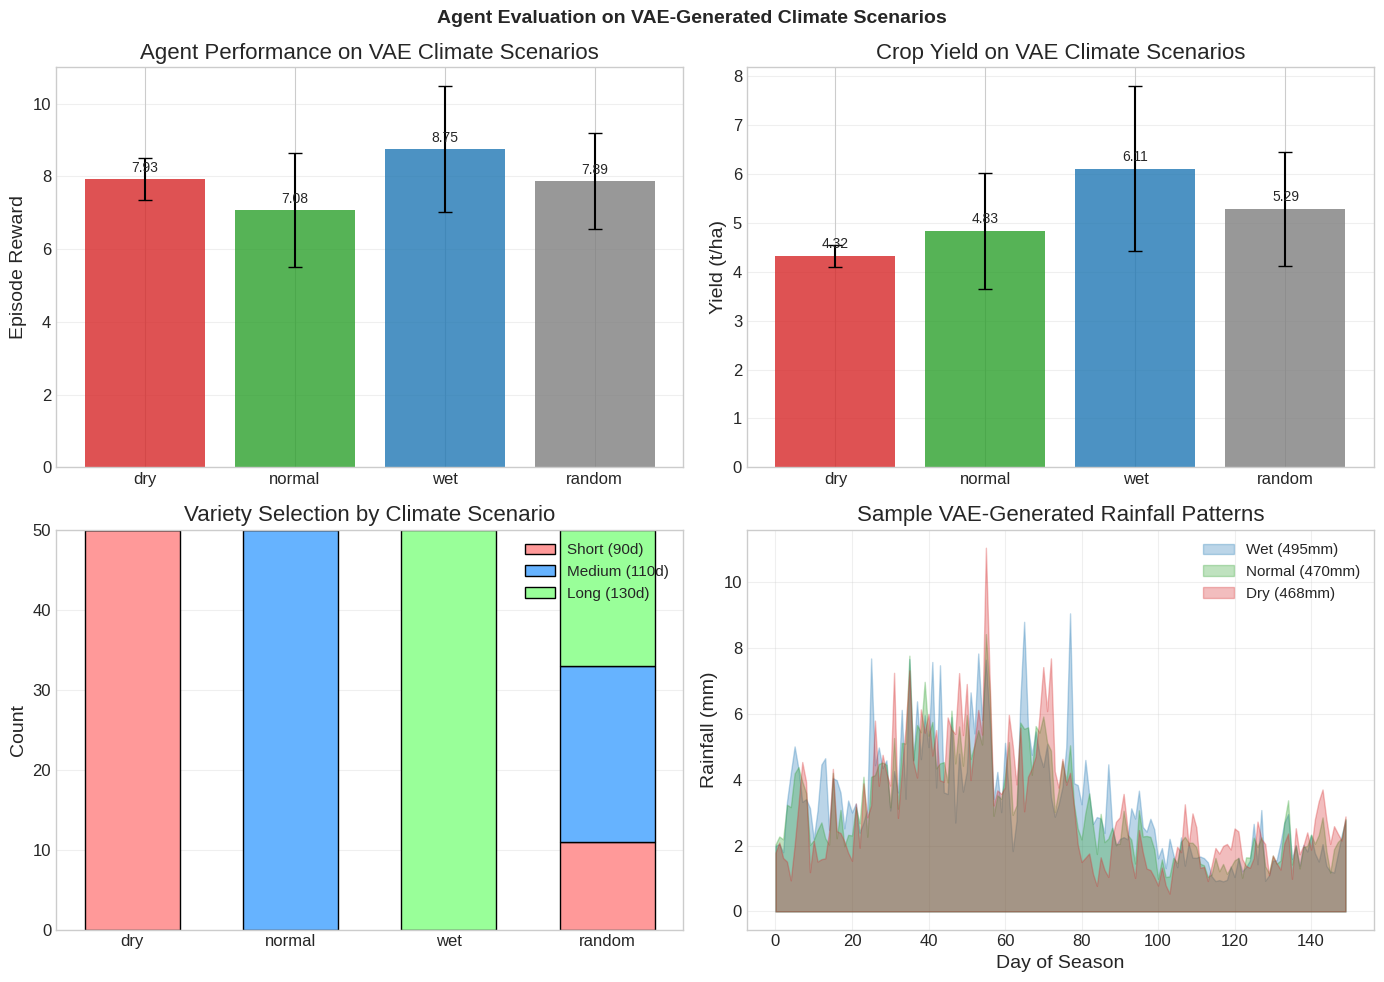


SUMMARY: VAE vs Historical Rainfall Performance

Historical rainfall (from training):
  Reward: 7.81 ± 1.58
  Yield:  5.16 ± 1.34 t/ha

VAE random scenarios:
  Reward: 7.89 ± 1.32
  Yield:  5.29 ± 1.17 t/ha


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scenarios = ['dry', 'normal', 'wet', 'random']
mean_rewards = [vae_results[s]['mean_reward'] for s in scenarios]
std_rewards = [vae_results[s]['std_reward'] for s in scenarios]
colors = ['#d62728', '#2ca02c', '#1f77b4', '#7f7f7f']

bars = axes[0, 0].bar(scenarios, mean_rewards, yerr=std_rewards, capsize=5, color=colors, alpha=0.8)
axes[0, 0].set_ylabel('Episode Reward')
axes[0, 0].set_title('Agent Performance on VAE Climate Scenarios')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mean_rewards):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', 
                   ha='center', va='bottom', fontsize=10)

mean_yields = [vae_results[s]['mean_yield'] for s in scenarios]
std_yields = [vae_results[s]['std_yield'] for s in scenarios]

bars = axes[0, 1].bar(scenarios, mean_yields, yerr=std_yields, capsize=5, color=colors, alpha=0.8)
axes[0, 1].set_ylabel('Yield (t/ha)')
axes[0, 1].set_title('Crop Yield on VAE Climate Scenarios')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, mean_yields):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', 
                   ha='center', va='bottom', fontsize=10)

var_names = ['Short (90d)', 'Medium (110d)', 'Long (130d)']
var_colors = ['#ff9999', '#66b3ff', '#99ff99']
x = np.arange(len(scenarios))
width = 0.6

bottom = np.zeros(len(scenarios))
for v_idx, (v_name, v_color) in enumerate(zip(var_names, var_colors)):
    counts = [vae_results[s]['varieties'].count(v_idx + 1) for s in scenarios]
    axes[1, 0].bar(x, counts, width, label=v_name, bottom=bottom, color=v_color, edgecolor='black')
    bottom += np.array(counts)

axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(scenarios)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Variety Selection by Climate Scenario')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].set_title('Sample VAE-Generated Rainfall Patterns')
sample_dry = vae_generator.generate_shifted(shift=-1.0, dim=0)
sample_normal = vae_generator.generate_shifted(shift=0.0, dim=0)
sample_wet = vae_generator.generate_shifted(shift=1.0, dim=0)

axes[1, 1].fill_between(range(150), sample_wet, alpha=0.3, label=f'Wet ({sample_wet.sum():.0f}mm)', color='#1f77b4')
axes[1, 1].fill_between(range(150), sample_normal, alpha=0.3, label=f'Normal ({sample_normal.sum():.0f}mm)', color='#2ca02c')
axes[1, 1].fill_between(range(150), sample_dry, alpha=0.3, label=f'Dry ({sample_dry.sum():.0f}mm)', color='#d62728')
axes[1, 1].set_xlabel('Day of Season')
axes[1, 1].set_ylabel('Rainfall (mm)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Agent Evaluation on VAE-Generated Climate Scenarios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("SUMMARY: VAE vs Historical Rainfall Performance")
print("="*60)

if 'eval_results' not in globals():
    if 'evaluate_agent' in globals():
        print("\n`eval_results` not found. Running historical evaluation now...")
        eval_results = evaluate_agent(env_test, agent, num_episodes=100)
    else:
        eval_results = None

if eval_results is not None:
    print(f"\nHistorical rainfall (from training):")
    print(f"  Reward: {eval_results['mean_reward']:.2f} ± {eval_results['std_reward']:.2f}")
    print(f"  Yield:  {eval_results['mean_yield']:.2f} ± {eval_results['std_yield']:.2f} t/ha")
else:
    print("\nHistorical rainfall (from training): unavailable (`evaluate_agent` not defined).")

print(f"\nVAE random scenarios:")
print(f"  Reward: {vae_results['random']['mean_reward']:.2f} ± {vae_results['random']['std_reward']:.2f}")
print(f"  Yield:  {vae_results['random']['mean_yield']:.2f} ± {vae_results['random']['std_yield']:.2f} t/ha")

Scanning variety selection across scale range...
  VAE rainfall pool...
  Historical rainfall...


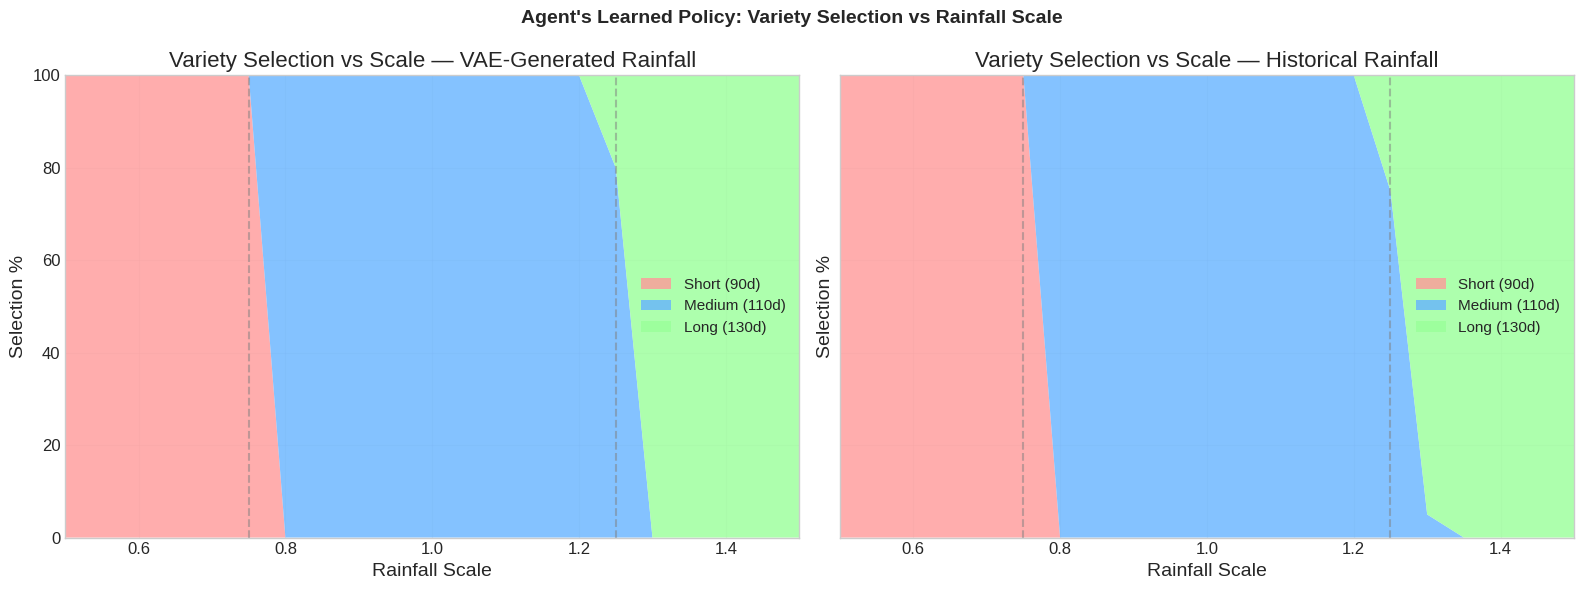


Variety selection (%) at key scale thresholds:
Scale     VAE Short    VAE Med   VAE Long |  Hist Short   Hist Med  Hist Long
-------------------------------------------------------------------------------------
0.50            100          0          0 |         100          0          0
0.60            100          0          0 |         100          0          0
0.70            100          0          0 |         100          0          0
0.75            100          0          0 |         100          0          0
1.00              0        100          0 |           0        100          0
1.25              0         80         20 |           0         75         25
1.30              0          0        100 |           0          5         95
1.40              0          0        100 |           0          0        100
1.50              0          0        100 |           0          0        100


In [ ]:
def scan_scale_variety(agent, rainfall_array, scale_values, episodes_per_scale=20):
    """Run episodes at each scale value and record variety choices."""
    env = gym.make('CropCalendar-v0', rainfall_data=rainfall_array, randomize_start=True)
    agent.eval()
    
    results = {s: [] for s in scale_values}
    
    for scale in scale_values:
        for _ in range(episodes_per_scale):
            state, _ = env.reset()
            env.unwrapped.rainfall_scale = scale
            state = env.unwrapped._get_obs()
            
            done = False
            variety = 0
            while not done:
                with torch.no_grad():
                    state_t = torch.FloatTensor(state).unsqueeze(0)
                    action, _, _, _ = agent.get_action(state_t, deterministic=True)
                    action = action.item()
                if action > 0 and variety == 0:
                    variety = action
                state, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
            results[scale].append(variety)
    env.close()
    return results

scale_values = np.round(np.arange(0.50, 1.55, 0.05), 2)

n_pool = 30
vae_pool = [np.maximum(0, vae_generator.generate_random(1)[0]) for _ in range(n_pool)]
vae_rainfall_long = np.concatenate(vae_pool)

print("Scanning variety selection across scale range...")
print("  VAE rainfall pool...")
vae_scan = scan_scale_variety(agent, vae_rainfall_long, scale_values, episodes_per_scale=20)
print("  Historical rainfall...")
hist_scan = scan_scale_variety(agent, rainfall_data, scale_values, episodes_per_scale=20)

def compute_fractions(scan_results, scale_values):
    short_frac, med_frac, long_frac = [], [], []
    for s in scale_values:
        choices = scan_results[s]
        n = len(choices)
        short_frac.append(choices.count(1) / n * 100)
        med_frac.append(choices.count(2) / n * 100)
        long_frac.append(choices.count(3) / n * 100)
    return short_frac, med_frac, long_frac

vae_short, vae_med, vae_long = compute_fractions(vae_scan, scale_values)
hist_short, hist_med, hist_long = compute_fractions(hist_scan, scale_values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, title, (sf, mf, lf) in zip(
    axes, ['VAE-Generated Rainfall', 'Historical Rainfall'],
    [(vae_short, vae_med, vae_long), (hist_short, hist_med, hist_long)]
):
    ax.stackplot(scale_values, sf, mf, lf,
                 labels=['Short (90d)', 'Medium (110d)', 'Long (130d)'],
                 colors=['#ff9999', '#66b3ff', '#99ff99'], alpha=0.8)
    ax.set_xlabel('Rainfall Scale')
    ax.set_ylabel('Selection %')
    ax.set_title(f'Variety Selection vs Scale — {title}')
    ax.legend(loc='center right')
    ax.set_xlim(0.5, 1.5)
    ax.set_ylim(0, 100)
    ax.axvline(0.75, color='gray', ls='--', alpha=0.5, label='Dry/Normal')
    ax.axvline(1.25, color='gray', ls='--', alpha=0.5, label='Normal/Wet')
    ax.grid(True, alpha=0.3)

plt.suptitle("Agent's Learned Policy: Variety Selection vs Rainfall Scale", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nVariety selection (%) at key scale thresholds:")
print(f"{'Scale':<8} {'VAE Short':>10} {'VAE Med':>10} {'VAE Long':>10} | {'Hist Short':>11} {'Hist Med':>10} {'Hist Long':>10}")
print("-" * 85)
for i, s in enumerate(scale_values):
    if s in [0.50, 0.60, 0.70, 0.75, 1.00, 1.25, 1.30, 1.40, 1.50]:
        print(f"{s:<8.2f} {vae_short[i]:>10.0f} {vae_med[i]:>10.0f} {vae_long[i]:>10.0f} | {hist_short[i]:>11.0f} {hist_med[i]:>10.0f} {hist_long[i]:>10.0f}")

## VAE vs Historical Rainfall — Agent Comparison

Comprehensive side-by-side comparison of the agent's behavior on:

- **Historical rainfall**: Real observed data with `randomize_start=True`
- **VAE-generated rainfall**: Synthetic data from the trained VAE world model

We compare: rewards, yields, variety distributions, scale-conditional behavior, and per-episode scatter.


Running matched historical evaluation by scenario...
Done.



/tmp/ipykernel_348657/775349070.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


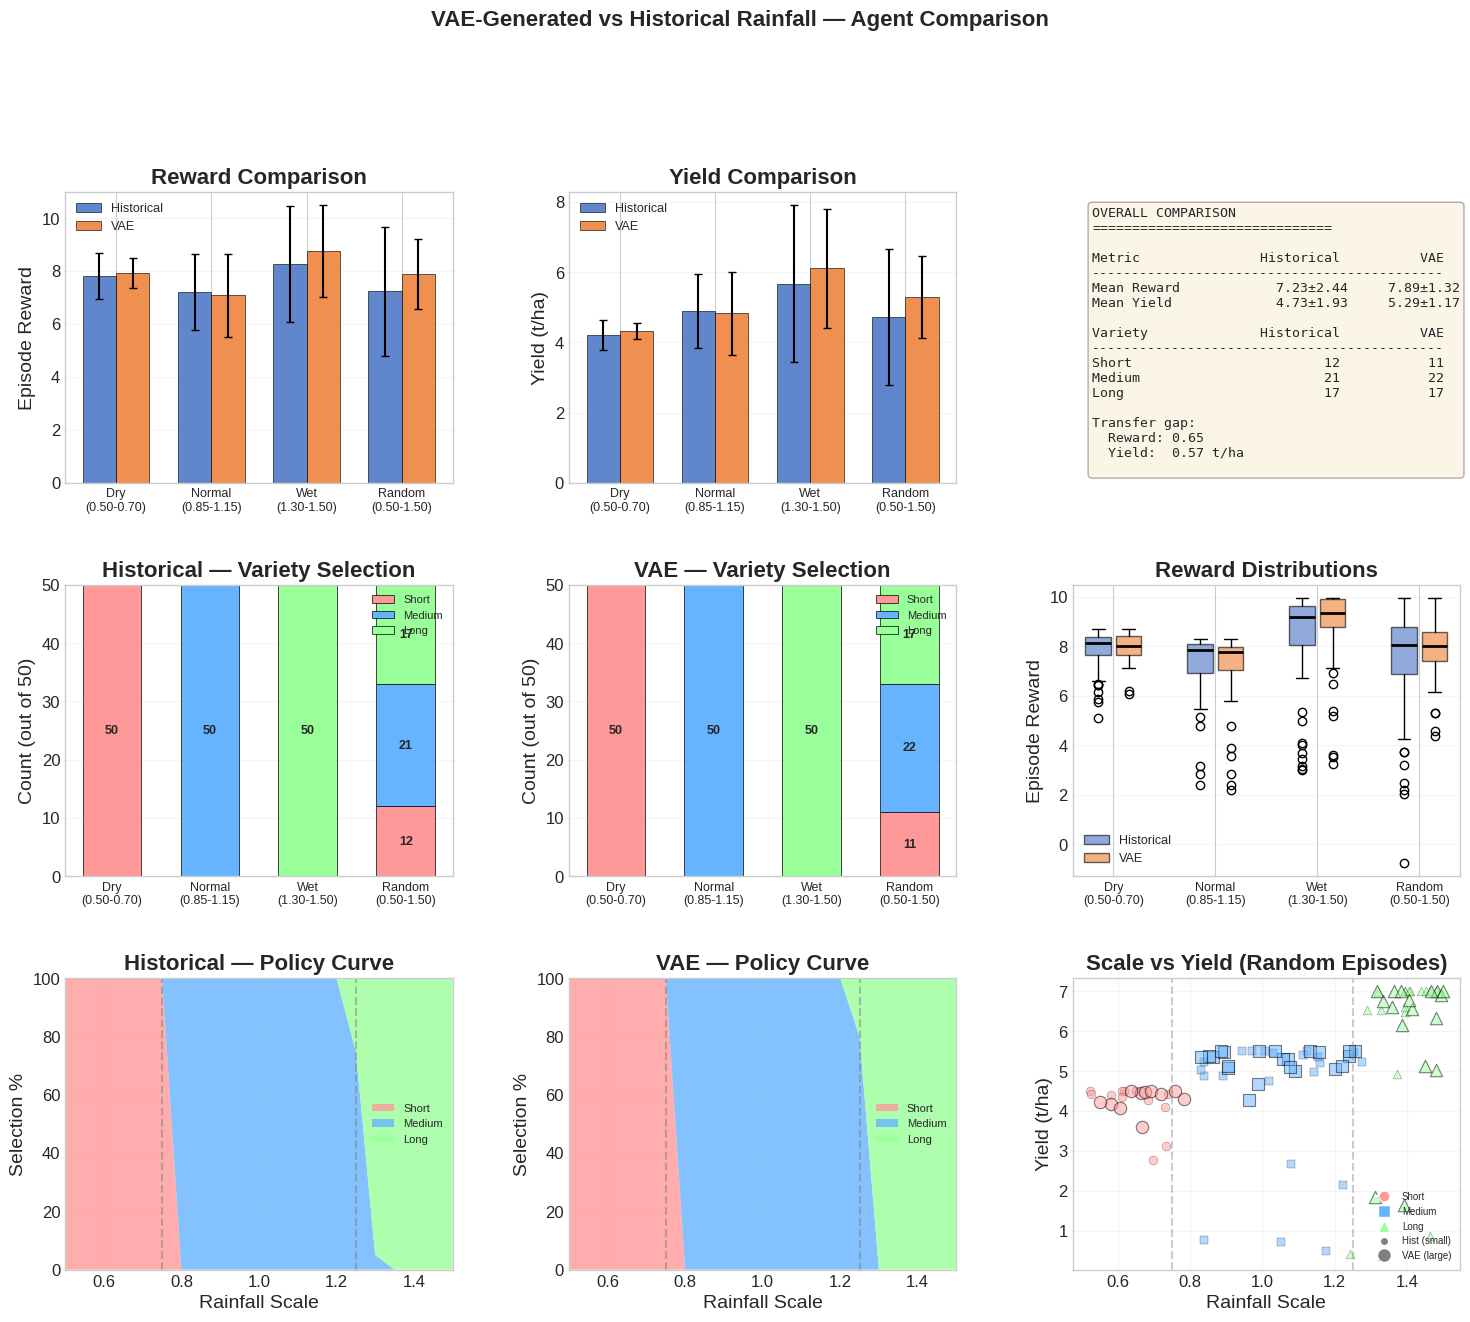


DETAILED COMPARISON: Historical vs VAE Rainfall

Scenario   Source             Reward   Yield (t/ha)   Short     Med    Long
--------------------------------------------------------------------------------
DRY        Historical     7.81±0.87     4.22±0.43      50       0       0
           VAE            7.93±0.57     4.32±0.22      50       0       0
           → Dominant                                 Short vs Short   ✓ MATCH

NORMAL     Historical     7.19±1.44     4.89±1.05       0      50       0
           VAE            7.08±1.56     4.83±1.19       0      50       0
           → Dominant                                Medium vs Medium  ✓ MATCH

WET        Historical     8.27±2.19     5.67±2.23       0       0      50
           VAE            8.75±1.72     6.11±1.69       0       0      50
           → Dominant                                  Long vs Long    ✓ MATCH

RANDOM     Historical     7.23±2.44     4.73±1.93      12      21      17
           VAE            7.89±1.32

In [ ]:
def evaluate_historical_by_scenario(agent, rainfall_data, num_episodes=50):
    """Evaluate on historical data with scenario-specific scale ranges (mirrors VAE eval)."""
    scale_ranges = {
        'dry':    (0.50, 0.70),
        'normal': (0.85, 1.15),
        'wet':    (1.30, 1.50),
        'random': (0.50, 1.50),
    }
    
    env = gym.make('CropCalendar-v0', rainfall_data=rainfall_data, randomize_start=True)
    agent.eval()
    
    all_results = {}
    for scenario, (lo, hi) in scale_ranges.items():
        results = {'rewards': [], 'yields': [], 'varieties': [], 'scales': []}
        
        for _ in range(num_episodes):
            state, _ = env.reset()
            target_scale = np.random.uniform(lo, hi)
            env.unwrapped.rainfall_scale = target_scale
            state = env.unwrapped._get_obs()
            results['scales'].append(target_scale)
            
            done, ep_reward, variety = False, 0, None
            while not done:
                with torch.no_grad():
                    st = torch.FloatTensor(state).unsqueeze(0)
                    action, _, _, _ = agent.get_action(st, deterministic=True)
                    action = action.item()
                if action > 0 and variety is None:
                    variety = action
                state, reward, terminated, truncated, info = env.step(action)
                ep_reward += reward
                done = terminated or truncated
            
            results['rewards'].append(ep_reward)
            results['yields'].append(info.get('current_yield', 0))
            results['varieties'].append(variety if variety else 0)
        
        results['mean_reward'] = np.mean(results['rewards'])
        results['std_reward'] = np.std(results['rewards'])
        results['mean_yield'] = np.mean(results['yields'])
        results['std_yield'] = np.std(results['yields'])
        results['mean_scale'] = np.mean(results['scales'])
        all_results[scenario] = results
    
    env.close()
    return all_results

print("Running matched historical evaluation by scenario...")
hist_results = evaluate_historical_by_scenario(agent, rainfall_data, num_episodes=50)
print("Done.\n")

scenarios = ['dry', 'normal', 'wet', 'random']
scenario_labels = ['Dry\n(0.50-0.70)', 'Normal\n(0.85-1.15)', 'Wet\n(1.30-1.50)', 'Random\n(0.50-1.50)']

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(scenarios))
w = 0.35
vae_rewards = [vae_results[s]['mean_reward'] for s in scenarios]
vae_reward_std = [vae_results[s]['std_reward'] for s in scenarios]
hist_rewards = [hist_results[s]['mean_reward'] for s in scenarios]
hist_reward_std = [hist_results[s]['std_reward'] for s in scenarios]

bars1 = ax1.bar(x - w/2, hist_rewards, w, yerr=hist_reward_std, capsize=3,
                label='Historical', color='#4472C4', alpha=0.85, edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + w/2, vae_rewards, w, yerr=vae_reward_std, capsize=3,
                label='VAE', color='#ED7D31', alpha=0.85, edgecolor='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(scenario_labels, fontsize=9)
ax1.set_ylabel('Episode Reward')
ax1.set_title('Reward Comparison', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2, axis='y')

ax2 = fig.add_subplot(gs[0, 1])
vae_yields = [vae_results[s]['mean_yield'] for s in scenarios]
vae_yield_std = [vae_results[s]['std_yield'] for s in scenarios]
hist_yields = [hist_results[s]['mean_yield'] for s in scenarios]
hist_yield_std = [hist_results[s]['std_yield'] for s in scenarios]

ax2.bar(x - w/2, hist_yields, w, yerr=hist_yield_std, capsize=3,
        label='Historical', color='#4472C4', alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.bar(x + w/2, vae_yields, w, yerr=vae_yield_std, capsize=3,
        label='VAE', color='#ED7D31', alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(scenario_labels, fontsize=9)
ax2.set_ylabel('Yield (t/ha)')
ax2.set_title('Yield Comparison', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis='y')

ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
summary_text = "OVERALL COMPARISON\n" + "=" * 30 + "\n\n"

hr = hist_results['random']
vr = vae_results['random']
summary_text += f"{'Metric':<18} {'Historical':>12} {'VAE':>12}\n"
summary_text += "-" * 44 + "\n"
summary_text += f"{'Mean Reward':<18} {hr['mean_reward']:>8.2f}±{hr['std_reward']:.2f} {vr['mean_reward']:>8.2f}±{vr['std_reward']:.2f}\n"
summary_text += f"{'Mean Yield':<18} {hr['mean_yield']:>8.2f}±{hr['std_yield']:.2f} {vr['mean_yield']:>8.2f}±{vr['std_yield']:.2f}\n\n"

h_vars = [hr['varieties'].count(v) for v in [1, 2, 3]]
v_vars = [vr['varieties'].count(v) for v in [1, 2, 3]]
summary_text += f"{'Variety':<18} {'Historical':>12} {'VAE':>12}\n"
summary_text += "-" * 44 + "\n"
for name, hc, vc in zip(['Short', 'Medium', 'Long'], h_vars, v_vars):
    summary_text += f"{name:<18} {hc:>12} {vc:>12}\n"

reward_gap = abs(vr['mean_reward'] - hr['mean_reward'])
yield_gap = abs(vr['mean_yield'] - hr['mean_yield'])
summary_text += f"\n{'Transfer gap:':<18}\n"
summary_text += f"  Reward: {reward_gap:.2f}\n"
summary_text += f"  Yield:  {yield_gap:.2f} t/ha\n"

ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes, fontsize=9.5,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

var_names = ['Short', 'Medium', 'Long']
var_colors = ['#ff9999', '#66b3ff', '#99ff99']

for col, (title, data) in enumerate(zip(
    ['Historical — Variety Selection', 'VAE — Variety Selection'],
    [hist_results, vae_results]
)):
    ax = fig.add_subplot(gs[1, col])
    bottom = np.zeros(len(scenarios))
    for v_idx, (v_name, v_color) in enumerate(zip(var_names, var_colors)):
        counts = [data[s]['varieties'].count(v_idx + 1) for s in scenarios]
        ax.bar(x, counts, 0.6, label=v_name, bottom=bottom, color=v_color, edgecolor='black', linewidth=0.5)
        for j, c in enumerate(counts):
            if c > 0:
                ax.text(j, bottom[j] + c/2, str(c), ha='center', va='center', fontsize=9, fontweight='bold')
        bottom += np.array(counts)
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_labels, fontsize=9)
    ax.set_ylabel('Count (out of 50)')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

ax6 = fig.add_subplot(gs[1, 2])
positions_h = np.arange(len(scenarios)) * 2
positions_v = positions_h + 0.6

hist_reward_data = [hist_results[s]['rewards'] for s in scenarios]
vae_reward_data = [vae_results[s]['rewards'] for s in scenarios]

bp_h = ax6.boxplot(hist_reward_data, positions=positions_h, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor='#4472C4', alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
bp_v = ax6.boxplot(vae_reward_data, positions=positions_v, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor="#000000", alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
ax6.set_xticks(positions_h + 0.3)
ax6.set_xticklabels(scenario_labels, fontsize=9)
ax6.set_ylabel('Episode Reward')
ax6.set_title('Reward Distributions', fontweight='bold')
ax6.legend([bp_h['boxes'][0], bp_v['boxes'][0]], ['Historical', 'VAE'], fontsize=9)
ax6.grid(True, alpha=0.2, axis='y')

scan_data = [
    ('Historical — Policy Curve', hist_short, hist_med, hist_long),
    ('VAE — Policy Curve', vae_short, vae_med, vae_long),
]
for col, (title, s_frac, m_frac, l_frac) in enumerate(scan_data):
    ax = fig.add_subplot(gs[2, col])
    ax.stackplot(scale_values, s_frac, m_frac, l_frac,
                labels=['Short', 'Medium', 'Long'], colors=var_colors, alpha=0.8)
    ax.axvline(0.75, color='gray', ls='--', alpha=0.5)
    ax.axvline(1.25, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Rainfall Scale')
    ax.set_ylabel('Selection %')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='center right', fontsize=8)
    ax.set_xlim(0.5, 1.5)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)

ax9 = fig.add_subplot(gs[2, 2])
variety_cmap = {1: '#ff9999', 2: '#66b3ff', 3: '#99ff99', 0: 'gray'}
variety_marker = {1: 'o', 2: 's', 3: '^', 0: 'x'}


for v in [1, 2, 3]:
    mask_h = [i for i, vv in enumerate(hist_results['random']['varieties']) if vv == v]
    if mask_h:
        sc_h = [hist_results['random']['scales'][i] for i in mask_h]
        yl_h = [hist_results['random']['yields'][i] for i in mask_h]
        ax9.scatter(sc_h, yl_h, c=variety_cmap[v], marker=variety_marker[v],
                alpha=0.5, s=40, edgecolors='black', linewidths=0.3)


for v in [1, 2, 3]:
    mask_v = [i for i, vv in enumerate(vae_results['random']['varieties']) if vv == v]
    if mask_v:
        sc_v = [vae_results['random']['scales'][i] for i in mask_v]
        yl_v = [vae_results['random']['yields'][i] for i in mask_v]
        ax9.scatter(sc_v, yl_v, c=variety_cmap[v], marker=variety_marker[v],
                alpha=0.5, s=80, edgecolors='black', linewidths=0.8)
        
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff9999', markersize=8, label='Short'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#66b3ff', markersize=8, label='Medium'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#99ff99', markersize=8, label='Long'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=6, label='Hist (small)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='VAE (large)'),
]
ax9.legend(handles=legend_elems, fontsize=7, loc='lower right')
ax9.axvline(0.75, color='gray', ls='--', alpha=0.4)
ax9.axvline(1.25, color='gray', ls='--', alpha=0.4)
ax9.set_xlabel('Rainfall Scale')
ax9.set_ylabel('Yield (t/ha)')
ax9.set_title('Scale vs Yield (Random Episodes)', fontweight='bold')
ax9.grid(True, alpha=0.2)

plt.suptitle('VAE-Generated vs Historical Rainfall — Agent Comparison',
            fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("DETAILED COMPARISON: Historical vs VAE Rainfall")
print("=" * 80)
print(f"\n{'Scenario':<10} {'Source':<12} {'Reward':>12} {'Yield (t/ha)':>14} {'Short':>7} {'Med':>7} {'Long':>7}")
print("-" * 80)
for s in scenarios:
    hr = hist_results[s]
    vr = vae_results[s]
    h_v = [hr['varieties'].count(v) for v in [1, 2, 3]]
    v_v = [vr['varieties'].count(v) for v in [1, 2, 3]]
    print(f"{s.upper():<10} {'Historical':<12} {hr['mean_reward']:>6.2f}±{hr['std_reward']:.2f} {hr['mean_yield']:>8.2f}±{hr['std_yield']:.2f} {h_v[0]:>7} {h_v[1]:>7} {h_v[2]:>7}")
    print(f"{'':10} {'VAE':<12} {vr['mean_reward']:>6.2f}±{vr['std_reward']:.2f} {vr['mean_yield']:>8.2f}±{vr['std_yield']:.2f} {v_v[0]:>7} {v_v[1]:>7} {v_v[2]:>7}")
    h_dominant = ['Short', 'Medium', 'Long'][h_v.index(max(h_v))]
    v_dominant = ['Short', 'Medium', 'Long'][v_v.index(max(v_v))]
    agree = "✓ MATCH" if h_dominant == v_dominant else "✗ DIFFER"
    print(f"{'':10} {'→ Dominant':<12} {'':>12} {'':>14} {h_dominant:>7} vs {v_dominant:<7} {agree}")
    print()


all_match = all(
    ['Short', 'Medium', 'Long'][([hist_results[s]['varieties'].count(v) for v in [1,2,3]]).index(max([hist_results[s]['varieties'].count(v) for v in [1,2,3]]))] ==
    ['Short', 'Medium', 'Long'][([vae_results[s]['varieties'].count(v) for v in [1,2,3]]).index(max([vae_results[s]['varieties'].count(v) for v in [1,2,3]]))]
    for s in scenarios
)
print(f"Policy transfer quality: {'✓ EXCELLENT — identical dominant variety across all scenarios' if all_match else '⚠ Partial — some scenario differences'}")

### Latent Space Interpolation Test

Testing agent across climate gradient (dry → wet)...
Shift → Scale mapping: latent shift controls pattern, rainfall_scale controls agent signal
----------------------------------------------------------------------
Shift -2.0σ (scale=0.50):  283mm | Reward: 7.98 | Yield: 4.35 | S=30, M= 0, L= 0
Shift -1.5σ (scale=0.62):  355mm | Reward: 8.07 | Yield: 4.36 | S=30, M= 0, L= 0
Shift -1.0σ (scale=0.75):  389mm | Reward: 5.73 | Yield: 4.40 | S=30, M= 0, L= 0
Shift -0.5σ (scale=0.88):  466mm | Reward: 7.23 | Yield: 4.95 | S= 0, M=30, L= 0
Shift +0.0σ (scale=1.00):  569mm | Reward: 7.28 | Yield: 4.98 | S= 0, M=30, L= 0
Shift +0.5σ (scale=1.12):  602mm | Reward: 7.71 | Yield: 5.25 | S= 0, M=30, L= 0
Shift +1.0σ (scale=1.25):  691mm | Reward: 6.72 | Yield: 5.16 | S= 0, M=23, L= 7
Shift +1.5σ (scale=1.38):  795mm | Reward: 9.22 | Yield: 6.54 | S= 0, M= 0, L=30
Shift +2.0σ (scale=1.50):  886mm | Reward: 9.20 | Yield: 6.62 | S= 0, M= 0, L=30


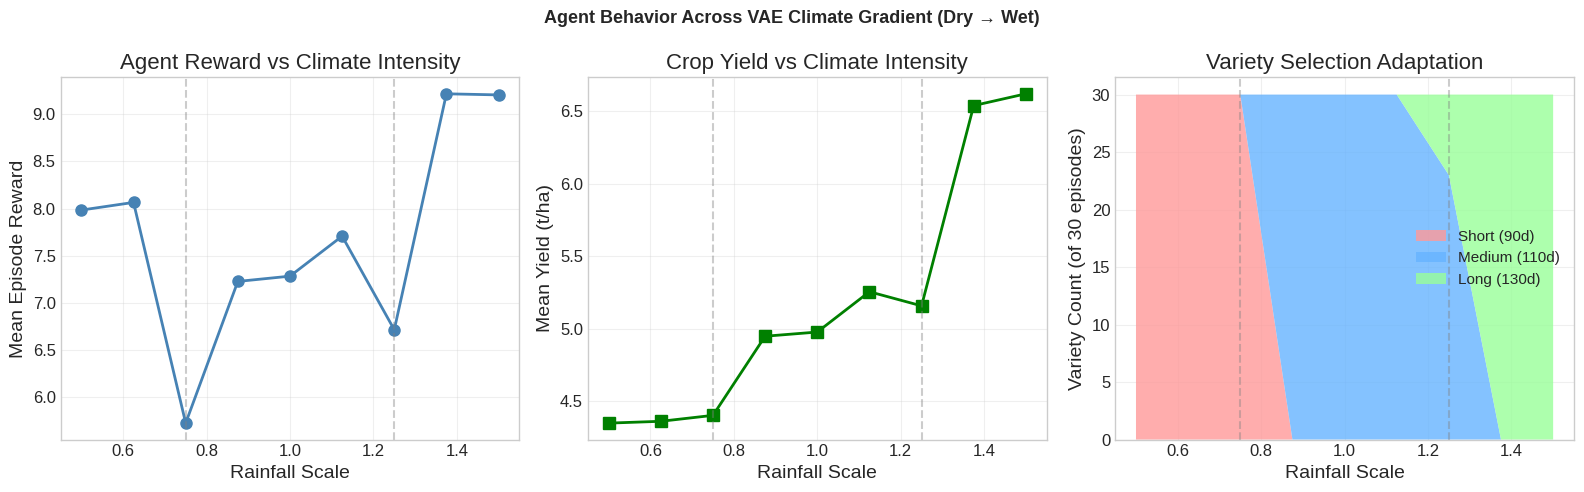

In [ ]:
shift_values = np.linspace(-2.0, 2.0, 9)  # Drought to very wet

# Map shift range [-2, 2] → scale range [0.5, 1.5]
def shift_to_scale(shift):
    return 0.5 + (shift + 2.0) / 4.0  # Linear: -2→0.5, 0→1.0, +2→1.5

interp_results = {
    'shift': [], 'scale': [], 'mean_reward': [], 'mean_yield': [],
    'total_rainfall': [], 'variety_dist': []
}

n_pool = 30
vae_pool = [np.maximum(0, vae_generator.generate_random(1)[0]) for _ in range(n_pool)]
vae_rainfall_long = np.concatenate(vae_pool)
env = gym.make('CropCalendar-v0', rainfall_data=vae_rainfall_long, randomize_start=True)

print("Testing agent across climate gradient (dry → wet)...")
print("Shift → Scale mapping: latent shift controls pattern, rainfall_scale controls agent signal")
print("-" * 70)

for shift in shift_values:
    scale = shift_to_scale(shift)
    rewards, yields, varieties, totals = [], [], [], []
    
    for _ in range(30):
        state, _ = env.reset()
        env.unwrapped.rainfall_scale = scale
        state = env.unwrapped._get_obs()
        
        offset = env.unwrapped.rainfall_offset
        season_len = env.unwrapped.season_duration
        raw_slice = vae_rainfall_long[offset:offset + season_len]
        totals.append(raw_slice.sum() * scale)
        
        done = False
        ep_reward = 0
        variety = None
        
        while not done:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0)
                action, _, _, _ = agent.get_action(state_t, deterministic=True)
                action = action.item()
            if action > 0 and variety is None:
                variety = action
            state, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            done = terminated or truncated
        
        rewards.append(ep_reward)
        yields.append(info.get('current_yield', 0))
        varieties.append(variety if variety else 0)
    
    interp_results['shift'].append(shift)
    interp_results['scale'].append(scale)
    interp_results['mean_reward'].append(np.mean(rewards))
    interp_results['mean_yield'].append(np.mean(yields))
    interp_results['total_rainfall'].append(np.mean(totals))
    interp_results['variety_dist'].append([varieties.count(1), varieties.count(2), varieties.count(3)])
    
    var_str = f"S={varieties.count(1):2d}, M={varieties.count(2):2d}, L={varieties.count(3):2d}"
    print(f"Shift {shift:+.1f}σ (scale={scale:.2f}): {np.mean(totals):4.0f}mm | Reward: {np.mean(rewards):.2f} | Yield: {np.mean(yields):.2f} | {var_str}")

env.close()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scales = interp_results['scale']
variety_array = np.array(interp_results['variety_dist'])

axes[0].plot(scales, interp_results['mean_reward'], 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Rainfall Scale')
axes[0].set_ylabel('Mean Episode Reward')
axes[0].set_title('Agent Reward vs Climate Intensity')
axes[0].axvline(0.75, color='gray', ls='--', alpha=0.4)
axes[0].axvline(1.25, color='gray', ls='--', alpha=0.4)
axes[0].grid(True, alpha=0.3)

axes[1].plot(scales, interp_results['mean_yield'], 's-', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Rainfall Scale')
axes[1].set_ylabel('Mean Yield (t/ha)')
axes[1].set_title('Crop Yield vs Climate Intensity')
axes[1].axvline(0.75, color='gray', ls='--', alpha=0.4)
axes[1].axvline(1.25, color='gray', ls='--', alpha=0.4)
axes[1].grid(True, alpha=0.3)

axes[2].stackplot(scales, variety_array[:, 0], variety_array[:, 1], variety_array[:, 2],
                labels=['Short (90d)', 'Medium (110d)', 'Long (130d)'],
                colors=['#ff9999', '#66b3ff', '#99ff99'], alpha=0.8)
axes[2].set_xlabel('Rainfall Scale')
axes[2].set_ylabel(f'Variety Count (of 30 episodes)')
axes[2].set_title('Variety Selection Adaptation')
axes[2].axvline(0.75, color='gray', ls='--', alpha=0.4)
axes[2].axvline(1.25, color='gray', ls='--', alpha=0.4)
axes[2].legend(loc='center right')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Agent Behavior Across VAE Climate Gradient (Dry → Wet)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualize Agent on VAE-Generated Season


In [ ]:
def visualize_vae_episode(agent, vae_gen, scenario='random', fps=5):
    """
    Visualize one episode using VAE-generated rainfall with pygame.
    
    Args:
        agent: Trained ActorCritic model
        vae_gen: RainfallVAEGenerator instance
        scenario: 'random', 'dry', 'normal', or 'wet'
        fps: Animation speed (lower = slower)
    """
    if scenario == 'random':
        rainfall = vae_gen.generate_random(1)[0]
    elif scenario == 'dry':
        rainfall = vae_gen.generate_shifted(shift=-1.5, dim=0)
    elif scenario == 'wet':
        rainfall = vae_gen.generate_shifted(shift=1.5, dim=0)
    else:
        rainfall = vae_gen.generate_shifted(shift=0.0, dim=0)
    
    rainfall = np.maximum(0, rainfall)
    total = rainfall.sum()
    
    print(f"VAE-Generated {scenario.upper()} Season: {total:.0f}mm total rainfall")
    print(f"Running pygame visualization (close window to stop)...")
    
    # Create environment with rendering
    env = gym.make('CropCalendar-v0', rainfall_data=rainfall, 
                randomize_start=False, render_mode='human')
    env.unwrapped.rainfall_scale = 1.0
    env.metadata['render_fps'] = fps
    
    agent.eval()
    state, _ = env.reset()
    done = False
    ep_reward = 0
    variety = None
    
    while not done:
        env.render()
        
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            action, _, _, _ = agent.get_action(state_t, deterministic=True)
            action = action.item()
        
        if action > 0 and variety is None:
            variety = action
            variety_names = {1: 'Short (90d)', 2: 'Medium (110d)', 3: 'Long (130d)'}
            print(f"  Planted {variety_names[action]} on day {env.unwrapped.current_day}")
        
        state, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        done = terminated or truncated
    
    print(f"  Final yield: {info.get('current_yield', 0):.2f} t/ha")
    print(f"  Episode reward: {ep_reward:.2f}")
    env.close()

